# (5) Where do linear and non-linear P(k) agree, and which datasets constrain cosmology alone?

**Questions**

1. At which scales are the *linear* P(k) (bacco linear via pyccl) and the *non-linear* P(k)
   the same vs different — as a function of redshift, of cosmology (ωₘ, σ₈), and of the
   CosmoHydro subgrid parameters?
2. Which observational datasets sit in the regime where the prediction depends on cosmology
   but is **insensitive to subgrid (baryonic-feedback) choices**? In particular: can the
   CMB-derived P(k) be used to constrain cosmology alone?

**Construction.** Three spectra are compared, all in k [h Mpc⁻¹], P [(h⁻¹Mpc)³]:

| spectrum | source | valid range |
|---|---|---|
| P_lin | bacco linear emulator (pyccl `BaccoemuLinear`) | all k plotted |
| P_NL (gravity-only) | MiraTitan-IV (pyccl `CosmicemuMTIVPk`) | k ≲ 5 h Mpc⁻¹, z ≤ 2 |
| P_hydro = Pk-ratio × P_NL | CosmoHydro `Pk-ratio` applied to MiraTitan-IV | k ∈ [0.016, 8], z ≤ 2 |

Note that here the baryonic suppression is applied to **MiraTitan-IV**, not to CosmoHydro's
own `Pk_GO` (as in nb2/nb3). This isolates the feedback signal from the gravity-only
emulator mismatch (the BAO-scale wiggles seen in nb3); `Pk-ratio` is exactly 1 below its
k-grid, so P_hydro = P_NL at k < 0.016.

Two characteristic scales are tracked throughout:
- **k_NL(z; thr)** — smallest k where |P_NL / P_lin − 1| > thr (2 %, 5 %, 20 %);
- **k_bar(z; thr)** — smallest k where |Pk-ratio − 1| > thr (1 %, 5 %).

Cosmology is fixed to Frontier-E (`../fixed_parameters.txt`) unless varied explicitly.
Observational k-ranges come from `../data_observational/` via `load_obs_data.py`.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import sys
import numpy as np
import matplotlib.pyplot as plt

import cosmohydro_emu as ce
import pyccl
from pyccl.emulators.cosmicemu_pk import CosmicemuMTIVPk
from pyccl.emulators.baccoemu_linear_pk import BaccoemuLinear

sys.path.insert(0, '../data_observational')
import load_obs_data

%matplotlib inline
plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

In [2]:
def load_fixed_params(path='../fixed_parameters.txt'):
    params = {}
    with open(path) as f:
        for line in f:
            line = line.split('#')[0].strip()
            if '=' in line:
                key, val = [s.strip() for s in line.split('=')]
                try:
                    params[key] = float(val)
                except ValueError:
                    params[key] = val
    return params

FP = load_fixed_params()
h = FP['h']
OM_FID, S8_FID = FP['omega_m'], FP['sigma_8']
P5_FID = [FP['kappa_w'], FP['e_w'], FP['M_seed'], FP['v_kin'], FP['epsilon_kin']]
P5_NAMES = [r'$\kappa_w$', r'$e_w$', r'$M_{seed}/10^6$', r'$v_{kin}/10^4$', r'$\epsilon_{kin}/10$']

bacco = BaccoemuLinear()
mt = CosmicemuMTIVPk('tot')
emu_ratio = ce.load_emulator('Pk-ratio')
k_ch = np.asarray(ce.get_x_grid('Pk_GO')[0])
P5_LO, P5_HI = emu_ratio.design.min(axis=0)[:5], emu_ratio.design.max(axis=0)[:5]
print('Pk-ratio subgrid box, lo:', P5_LO, ' hi:', P5_HI)

KMAX = 5.0                                     # MiraTitan-IV validity
k_th = np.logspace(np.log10(0.005), np.log10(KMAX), 300)

def make_cosmo(om, s8):
    Ob = FP['Omega_b_h2'] / h**2
    return pyccl.Cosmology(Omega_c=om / h**2 - Ob, Omega_b=Ob, h=h, sigma8=s8,
                           n_s=FP['n_s'], w0=FP['w0'], wa=FP['wa'],
                           transfer_function='bbks')   # emulators use params only

_cache = {}
def spectra(om, s8, z, k):
    # (P_lin, P_NL) on k [h/Mpc] in (Mpc/h)^3; P_lin from bacco, P_NL from MiraTitan-IV
    if (om, s8) not in _cache:
        c = make_cosmo(om, s8)
        _cache[(om, s8)] = (c, bacco.get_pk2d(c), mt.get_pk2d(c))
    c, pl2d, pm2d = _cache[(om, s8)]
    a = 1.0 / (1.0 + z)
    k = np.asarray(k)
    return pl2d(k * h, a, c) * h**3, pm2d(k * h, a, c) * h**3

def baryon_ratio(p5, om, s8, z, k):
    # CosmoHydro Pk-ratio interpolated onto k; =1 below its grid (checked: ratio(k_min)=1)
    r, _ = emu_ratio.predict(list(p5) + [om, s8], z=z)
    return np.interp(np.log(np.asarray(k)), np.log(k_ch), r, left=1.0, right=np.nan)

def first_k(k, dev, thr, kmin=0.03):
    # smallest k >= kmin where dev > thr (nan if never)
    idx = np.where((k >= kmin) & (dev > thr))[0]
    return k[idx[0]] if len(idx) else np.nan

# Observational k-ranges (linear datasets are quoted as z = 0 linear-equivalent P(k))
obs = load_obs_data.load_all_linear(h=h)
kids = load_obs_data.load_kids_legacy(nz='nz3', z_bins=[0.15, 0.45])
datasets = []
for d in obs:
    datasets.append(dict(label=d['label'], k=np.asarray(d['k']), P=np.asarray(d['P']),
                         err=np.asarray(d['err']), z=0.0))
for zf in [0.15, 0.45]:
    s = kids['z'] == zf
    datasets.append(dict(label=f'KiDS-Legacy $P_m$ ($z_{{fid}}$={zf})', k=kids['k'][s],
                         P=kids['P'][s], err=kids['err'][s], z=zf))
DS_COLORS = ['darkgoldenrod', 'royalblue', 'forestgreen', 'purple', 'mediumorchid']

def draw_data_bands(ax, axis='x', alpha=0.07, label=True):
    for d, c in zip(datasets, DS_COLORS):
        lo, hi = d['k'].min(), min(d['k'].max(), KMAX)
        span = ax.axvspan if axis == 'x' else ax.axhspan
        span(lo, hi, color=c, alpha=alpha, lw=0, label=d['label'] if label else None)

print(f"{'dataset':38s} {'z':>5s} {'k_min':>7s} {'k_max':>7s} {'N':>4s} {'median err/P':>13s}")
for d in datasets:
    print(f"{d['label']:38s} {d['z']:5.2f} {d['k'].min():7.4f} {d['k'].max():7.3f} "
          f"{len(d['k']):4d} {np.median(d['err'] / d['P']):13.3f}")

Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator Arico et al. (2021)...
Baryonic Emulator Arico et al. (2025) loaded in memory.


Pk-ratio subgrid box, lo: [2.   0.2  0.6  0.1  0.02]  hi: [4.  1.  2.  1.2 1.2]
dataset                                    z   k_min   k_max    N  median err/P
eBOSS DR14 Ly$\alpha$ (Chabanier+19)    0.00  0.3070   3.726   19         0.320
SDSS DR7 LRG (Reid+10)                  0.00  0.0329   0.296   45         0.070
CMB: WMAP+ACT (Hlozek+12)               0.00  0.0052   0.045    8         0.076
KiDS-Legacy $P_m$ ($z_{fid}$=0.15)      0.15  0.0101  19.811   20         0.290
KiDS-Legacy $P_m$ ($z_{fid}$=0.45)      0.45  0.0101  19.811   20         0.329


## A. Linear vs non-linear vs redshift (fiducial cosmology and subgrid)

Top: gravity-only non-linear boost P_NL / P_lin; bottom: the baryonic factor
P_hydro / P_NL = `Pk-ratio`. Shaded bands are the k-ranges covered by each dataset.
Both effects move to smaller k (larger scales) as z decreases.

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


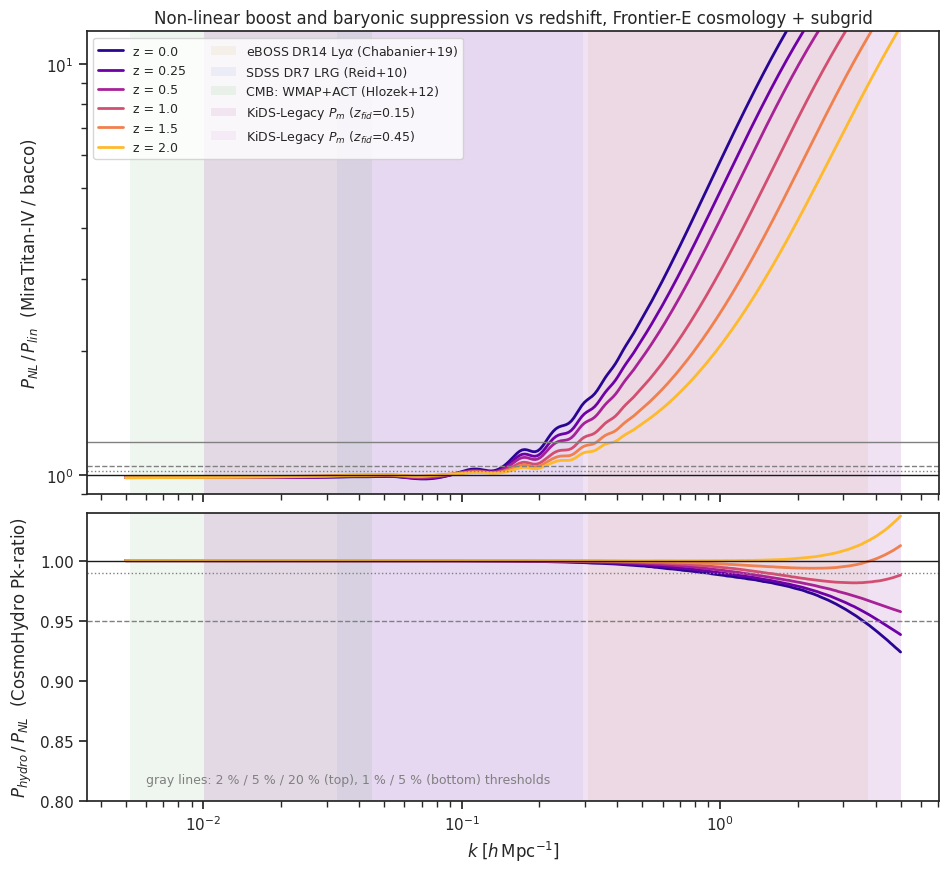

In [3]:
Z_LIST = [0.0, 0.25, 0.5, 1.0, 1.5, 2.0]
zcolors = plt.cm.plasma(np.linspace(0.05, 0.85, len(Z_LIST)))

fig, (ax, axb) = plt.subplots(2, 1, figsize=(11, 10), sharex=True,
                              gridspec_kw={'height_ratios': [1.6, 1], 'hspace': 0.05})
for z, c in zip(Z_LIST, zcolors):
    p_lin, p_nl = spectra(OM_FID, S8_FID, z, k_th)
    r = baryon_ratio(P5_FID, OM_FID, S8_FID, z, k_th)
    ax.loglog(k_th, p_nl / p_lin, color=c, lw=2, label=f'z = {z}')
    axb.semilogx(k_th, r, color=c, lw=2)
draw_data_bands(ax); draw_data_bands(axb, label=False)
for thr, ls in [(0.02, ':'), (0.05, '--'), (0.20, '-')]:
    ax.axhline(1 + thr, color='gray', lw=1, ls=ls)
ax.axhline(1, color='k', lw=1)
ax.set_ylim(0.9, 12); ax.set_ylabel(r'$P_{NL}\,/\,P_{lin}$  (MiraTitan-IV / bacco)')
ax.set_title('Non-linear boost and baryonic suppression vs redshift, Frontier-E cosmology + subgrid')
ax.legend(fontsize=9, loc='upper left', ncol=2)
for thr, ls in [(0.01, ':'), (0.05, '--')]:
    axb.axhline(1 - thr, color='gray', lw=1, ls=ls)
axb.axhline(1, color='k', lw=1)
axb.set_ylim(0.8, 1.04); axb.set_ylabel(r'$P_{hydro}\,/\,P_{NL}$  (CosmoHydro Pk-ratio)')
axb.set_xlabel(r'$k\;[h\,{\rm Mpc}^{-1}]$')
axb.text(0.006, 0.815, 'gray lines: 2 % / 5 % / 20 % (top), 1 % / 5 % (bottom) thresholds',
         fontsize=9, color='gray')
plt.tight_layout(); plt.show()

### Characteristic scales k_NL(z) and k_bar(z)

The smallest k at which the non-linear boost (thresholds 2 %, 5 %, 20 %) and the baryonic
suppression (1 %, 5 %) exceed the threshold, versus redshift. Horizontal bands: dataset
k-ranges. A dataset lies in the "linear, baryon-free" regime at a given z only if its
whole k-range sits **below** both curves.

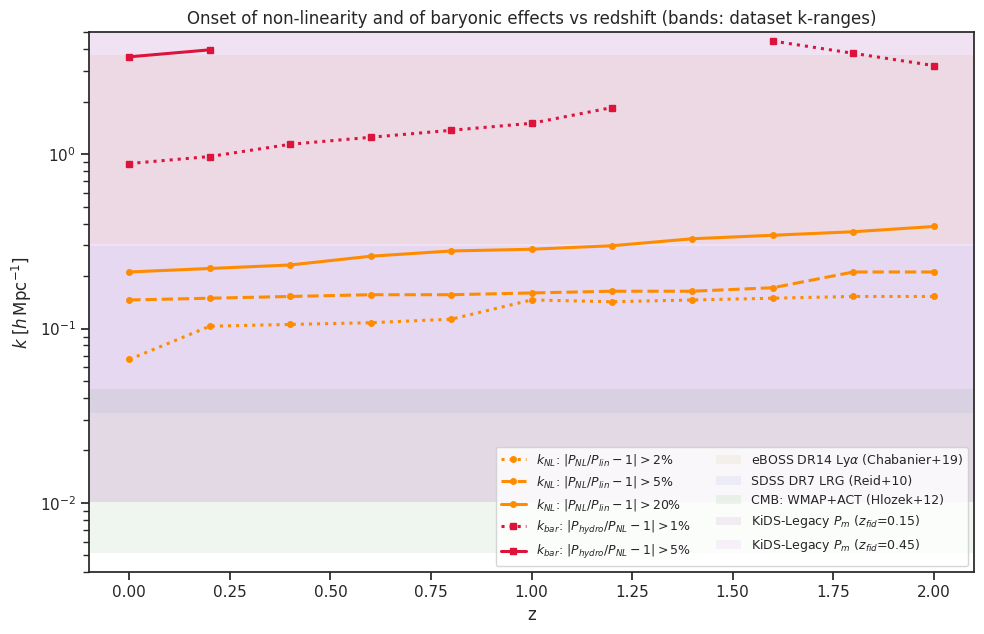

z     k_NL>2%  k_NL>5%  k_NL>20%   k_bar>1%  k_bar>5%
 0.0    0.066    0.146    0.211      0.884     3.618
 0.2    0.103    0.149    0.221      0.970     3.969
 0.4    0.106    0.153    0.231      1.140       nan
 0.6    0.108    0.156    0.260      1.250       nan
 0.8    0.113    0.156    0.278      1.371       nan
 1.0    0.146    0.160    0.285      1.504       nan
 1.2    0.143    0.164    0.298      1.852       nan
 1.4    0.146    0.164    0.327        nan       nan
 1.6    0.149    0.171    0.343      4.455       nan
 1.8    0.153    0.211    0.359      3.789       nan
 2.0    0.153    0.211    0.385      3.224       nan


In [4]:
z_fine = np.linspace(0.0, 2.0, 11)
NL_THR, BAR_THR = [0.02, 0.05, 0.20], [0.01, 0.05]
k_nl = {t: [] for t in NL_THR}
k_bar = {t: [] for t in BAR_THR}
for z in z_fine:
    p_lin, p_nl = spectra(OM_FID, S8_FID, z, k_th)
    r = baryon_ratio(P5_FID, OM_FID, S8_FID, z, k_th)
    for t in NL_THR:
        k_nl[t].append(first_k(k_th, np.abs(p_nl / p_lin - 1), t))
    for t in BAR_THR:
        k_bar[t].append(first_k(k_th, np.abs(r - 1), t))

fig, ax = plt.subplots(figsize=(10, 6.5))
for t, ls in zip(NL_THR, [':', '--', '-']):
    ax.plot(z_fine, k_nl[t], color='darkorange', lw=2.2, ls=ls, marker='o', ms=4,
            label=f'$k_{{NL}}$: $|P_{{NL}}/P_{{lin}}-1| > {t*100:.0f}\\%$')
for t, ls in zip(BAR_THR, [':', '-']):
    ax.plot(z_fine, k_bar[t], color='crimson', lw=2.2, ls=ls, marker='s', ms=4,
            label=f'$k_{{bar}}$: $|P_{{hydro}}/P_{{NL}}-1| > {t*100:.0f}\\%$')
draw_data_bands(ax, axis='y')
ax.set_yscale('log'); ax.set_ylim(4e-3, KMAX)
ax.set_xlabel('z'); ax.set_ylabel(r'$k\;[h\,{\rm Mpc}^{-1}]$')
ax.set_title('Onset of non-linearity and of baryonic effects vs redshift (bands: dataset k-ranges)')
ax.legend(fontsize=9, loc='lower right', ncol=2)
plt.tight_layout(); plt.show()

print('z     ' + '  '.join(f'k_NL>{t:.0%}' for t in NL_THR) + '   ' + '  '.join(f'k_bar>{t:.0%}' for t in BAR_THR))
for i, z in enumerate(z_fine):
    print(f'{z:4.1f}  ' + '  '.join(f'{k_nl[t][i]:7.3f}' for t in NL_THR) + '   '
          + '  '.join(f'{k_bar[t][i]:8.3f}' for t in BAR_THR))

## B. Varying cosmology (ωₘ, σ₈)

3 × 3 grid spanning the common CosmoHydro / MiraTitan-IV box (ωₘ ∈ [0.12, 0.155],
σ₈ ∈ [0.7, 0.9], values kept slightly inside the edges). Left/middle: the non-linear
boost at z = 0 and z = 1 — σ₈ controls the amplitude of non-linearity and hence k_NL.
Right: the baryonic factor at fixed Frontier-E subgrid parameters — its cosmology
dependence is weak compared to the subgrid dependence in section C.

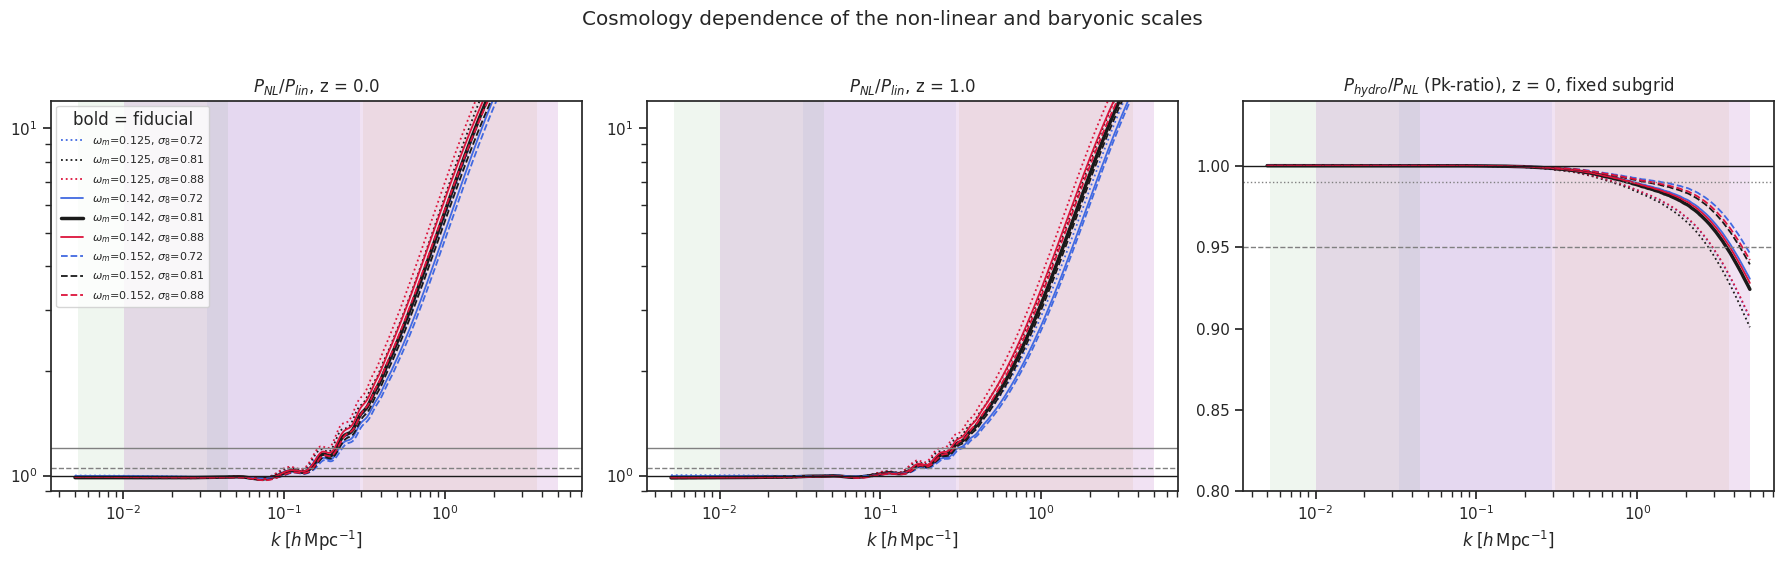

omega_m  sigma_8   k_NL>5%  k_NL>20%   k_bar>1%  k_bar>5%   (z = 0)
 0.1250   0.720     0.143     0.211      0.718     2.939
 0.1250   0.810     0.106     0.202      0.702     2.806
 0.1250   0.880     0.101     0.164      0.718     2.939
 0.1418   0.720     0.149     0.221      0.947     3.878
 0.1418   0.810     0.146     0.211      0.884     3.618
 0.1418   0.880     0.146     0.206      0.926     3.789
 0.1520   0.720     0.156     0.231      1.403     4.774
 0.1520   0.810     0.153     0.221      1.140     4.353
 0.1520   0.880     0.153     0.216      1.222     4.559


In [5]:
OM_LIST = [0.125, OM_FID, 0.152]
S8_LIST = [0.72, S8_FID, 0.88]
s8_col = {0.72: 'royalblue', S8_FID: 'k', 0.88: 'crimson'}
om_ls = {0.125: ':', OM_FID: '-', 0.152: '--'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
rows = []
for om in OM_LIST:
    for s8 in S8_LIST:
        lw = 2.5 if (om == OM_FID and s8 == S8_FID) else 1.3
        for ax, z in zip(axes[:2], [0.0, 1.0]):
            p_lin, p_nl = spectra(om, s8, z, k_th)
            ax.loglog(k_th, p_nl / p_lin, color=s8_col[s8], ls=om_ls[om], lw=lw,
                      label=f'$\omega_m$={om:.3f}, $\sigma_8$={s8:.2f}' if z == 0 else None)
        r0 = baryon_ratio(P5_FID, om, s8, 0.0, k_th)
        axes[2].semilogx(k_th, r0, color=s8_col[s8], ls=om_ls[om], lw=lw)
        p_lin, p_nl = spectra(om, s8, 0.0, k_th)
        rows.append((om, s8, first_k(k_th, np.abs(p_nl / p_lin - 1), 0.05),
                     first_k(k_th, np.abs(p_nl / p_lin - 1), 0.20),
                     first_k(k_th, np.abs(r0 - 1), 0.01), first_k(k_th, np.abs(r0 - 1), 0.05)))
for ax, z in zip(axes[:2], [0.0, 1.0]):
    ax.axhline(1.05, color='gray', lw=1, ls='--'); ax.axhline(1.2, color='gray', lw=1)
    ax.axhline(1, color='k', lw=1); draw_data_bands(ax, label=False)
    ax.set_ylim(0.9, 12); ax.set_title(f'$P_{{NL}}/P_{{lin}}$, z = {z}')
    ax.set_xlabel(r'$k\;[h\,{\rm Mpc}^{-1}]$')
axes[0].legend(fontsize=8, loc='upper left', title='bold = fiducial')
axes[2].axhline(0.99, color='gray', lw=1, ls=':'); axes[2].axhline(0.95, color='gray', lw=1, ls='--')
axes[2].axhline(1, color='k', lw=1); draw_data_bands(axes[2], label=False)
axes[2].set_ylim(0.8, 1.04); axes[2].set_title('$P_{hydro}/P_{NL}$ (Pk-ratio), z = 0, fixed subgrid')
axes[2].set_xlabel(r'$k\;[h\,{\rm Mpc}^{-1}]$')
plt.suptitle('Cosmology dependence of the non-linear and baryonic scales', y=1.02)
plt.tight_layout(); plt.show()

print('omega_m  sigma_8   k_NL>5%  k_NL>20%   k_bar>1%  k_bar>5%   (z = 0)')
for om, s8, a, b, c, d in rows:
    print(f'{om:7.4f}  {s8:6.3f}   {a:7.3f}  {b:8.3f}   {c:8.3f}  {d:8.3f}')

## C. Varying subgrid parameters

One-at-a-time sweeps of each CosmoHydro subgrid parameter across the `Pk-ratio` training
box (others at Frontier-E values), plus the **envelope** over a 200-point random sample of
the full 5-D box. The envelope is the "subgrid uncertainty" used in section D: at a given
k, |Pk-ratio − 1| can be anything inside the shaded region depending on feedback choices.

parameter        value    k_bar>1%  k_bar>5%   (z = 0)
$\kappa_w$         2.00      0.702     2.806
$\kappa_w$         2.50      0.752     3.078
$\kappa_w$         3.00      0.884     3.618
$\kappa_w$         3.50      1.340     4.665
$\kappa_w$         4.00      3.224       nan
$e_w$              0.20      0.770     3.150
$e_w$              0.40      0.825     3.455
$e_w$              0.60      0.926     3.789
$e_w$              0.80      1.114     4.353
$e_w$              1.00      1.650     5.000
$M_{seed}/10^6$    0.60      0.926     3.789
$M_{seed}/10^6$    0.95      0.844     3.536
$M_{seed}/10^6$    1.30      0.806     3.299
$M_{seed}/10^6$    1.65      0.752     3.078
$M_{seed}/10^6$    2.00      0.702     2.872


$v_{kin}/10^4$     0.10      4.253       nan
$v_{kin}/10^4$     0.38      1.039     4.156
$v_{kin}/10^4$     0.65      0.825     3.376
$v_{kin}/10^4$     0.92      0.806     3.376
$v_{kin}/10^4$     1.20      0.788     3.224


$\epsilon_{kin}/10$   0.02      2.559       nan
$\epsilon_{kin}/10$   0.32      0.640     2.559
$\epsilon_{kin}/10$   0.61      0.597     2.177
$\epsilon_{kin}/10$   0.91      0.557     1.984
$\epsilon_{kin}/10$   1.20      0.611     2.279


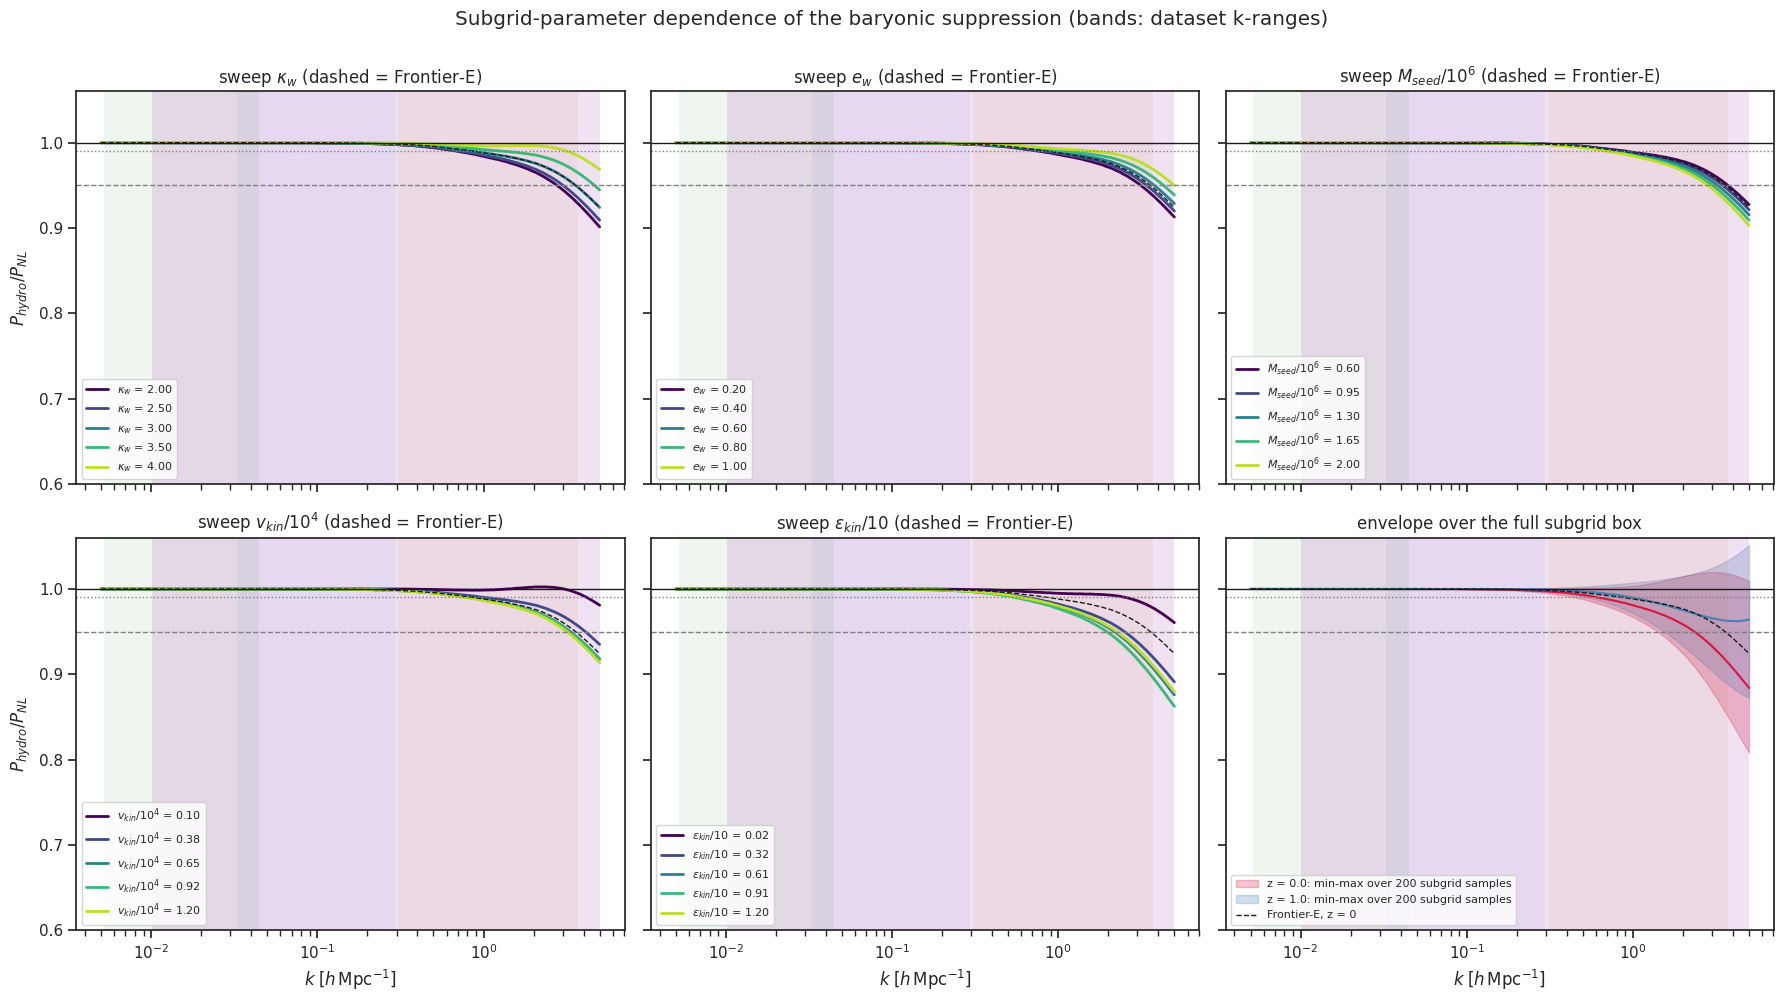


Envelope at z = 0: max |Pk-ratio - 1| over the box exceeds 1% for k > 0.452, 5% for k > 1.436 h/Mpc


In [6]:
rng = np.random.default_rng(42)
N_LHS = 200
P5_SAMPLES = P5_LO + rng.random((N_LHS, 5)) * (P5_HI - P5_LO)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.ravel()
sweep_cols = plt.cm.viridis(np.linspace(0, 0.9, 5))
print('parameter        value    k_bar>1%  k_bar>5%   (z = 0)')
for i, (ax, name) in enumerate(zip(axes[:5], P5_NAMES)):
    for v, c in zip(np.linspace(P5_LO[i], P5_HI[i], 5), sweep_cols):
        p5 = list(P5_FID); p5[i] = v
        r = baryon_ratio(p5, OM_FID, S8_FID, 0.0, k_th)
        ax.semilogx(k_th, r, color=c, lw=2, label=f'{name} = {v:.2f}')
        print(f'{name:16s} {v:6.2f}   {first_k(k_th, np.abs(r-1), 0.01):8.3f}  '
              f'{first_k(k_th, np.abs(r-1), 0.05):8.3f}')
    r_fid = baryon_ratio(P5_FID, OM_FID, S8_FID, 0.0, k_th)
    ax.semilogx(k_th, r_fid, color='k', lw=1, ls='--')
    ax.legend(fontsize=8, loc='lower left'); ax.set_title(f'sweep {name} (dashed = Frontier-E)')

# envelope over the random sample, z = 0 and z = 1
ax = axes[5]
env = {}
for z, c in [(0.0, 'crimson'), (1.0, 'steelblue')]:
    R = np.array([baryon_ratio(p5, OM_FID, S8_FID, z, k_th) for p5 in P5_SAMPLES])
    env[z] = R
    ax.fill_between(k_th, R.min(axis=0), R.max(axis=0), color=c, alpha=0.25,
                    label=f'z = {z}: min-max over {N_LHS} subgrid samples')
    ax.semilogx(k_th, np.median(R, axis=0), color=c, lw=1.5)
ax.semilogx(k_th, r_fid, color='k', lw=1, ls='--', label='Frontier-E, z = 0')
ax.legend(fontsize=8, loc='lower left'); ax.set_title('envelope over the full subgrid box')
for ax in axes:
    ax.axhline(1, color='k', lw=1); ax.axhline(0.99, color='gray', lw=1, ls=':')
    ax.axhline(0.95, color='gray', lw=1, ls='--'); draw_data_bands(ax, label=False)
    ax.set_ylim(0.6, 1.06)
for ax in axes[3:]:
    ax.set_xlabel(r'$k\;[h\,{\rm Mpc}^{-1}]$')
for ax in axes[::3]:
    ax.set_ylabel(r'$P_{hydro}/P_{NL}$')
plt.suptitle('Subgrid-parameter dependence of the baryonic suppression (bands: dataset k-ranges)', y=1.0)
plt.tight_layout(); plt.show()

dev0 = np.abs(env[0.0] - 1).max(axis=0)
print(f"\nEnvelope at z = 0: max |Pk-ratio - 1| over the box exceeds 1% for k > "
      f"{first_k(k_th, dev0, 0.01):.3f}, 5% for k > {first_k(k_th, dev0, 0.05):.3f} h/Mpc")

## D. Which datasets constrain cosmology without subgrid contamination?

For every data point we compare four fractional quantities at the dataset's redshift:

- **measurement error** σ_P / P (points);
- **non-linear boost** |P_NL / P_lin − 1| (fiducial cosmology) — where linear theory
  cannot be used;
- **subgrid envelope** max |Pk-ratio − 1| over the 200-point subgrid sample — the size of
  the baryonic nuisance if feedback is *unknown*;
- **cosmological signal** |Δ ln P_lin| for a shift Δσ₈ = +0.02 and, separately,
  Δωₘ = +0.005 (Planck-like precision, and the size of the S₈ tension).

A dataset can constrain cosmology *alone* where the cosmological signal exceeds the error
while the subgrid envelope is well below the error. (Reminder: the linear datasets are
already *quoted* as z = 0 linear-equivalent P(k) by their authors; the non-linear boost
here shows where that deprojection itself relied on a non-linear model.)

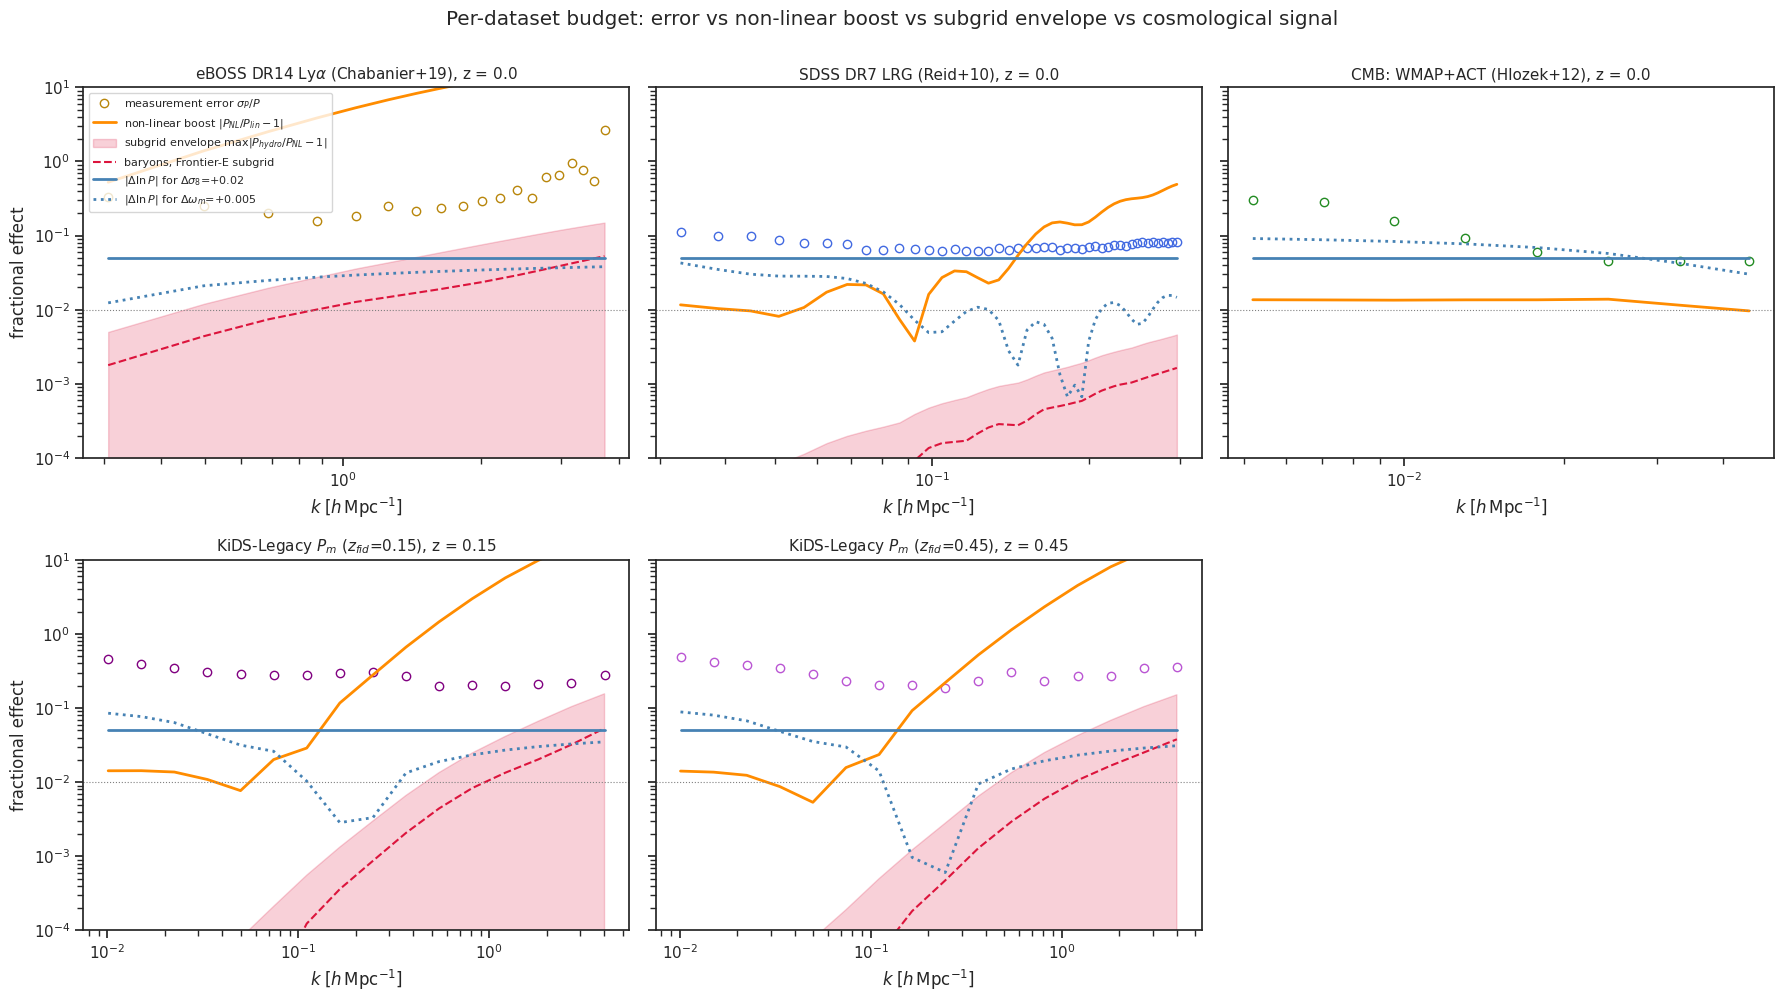

dataset                                   z       k-range  med err  NL max subgrid max  sig(s8)  sig(om) subgrid/sig sig/err pts subgrid>err  verdict
eBOSS DR14 Ly$\alpha$ (Chabanier+19)   0.00  0.307- 3.726    0.320  22.345      0.1495    0.050    0.034       2.992    0.16        0/19     needs feedback model
SDSS DR7 LRG (Reid+10)                 0.00  0.033- 0.296    0.070   0.491      0.0046    0.050    0.009       0.093    0.71        0/45     cosmology-only
CMB: WMAP+ACT (Hlozek+12)              0.00  0.005- 0.045    0.076   0.014      0.0001    0.050    0.073       0.001    0.69        0/8      cosmology-only
KiDS-Legacy $P_m$ ($z_{fid}$=0.15)     0.15  0.010- 4.015    0.279  21.253      0.1559    0.050    0.029       3.118    0.18        0/16     needs feedback model
KiDS-Legacy $P_m$ ($z_{fid}$=0.45)     0.45  0.010- 4.015    0.280  18.166      0.1512    0.050    0.028       3.026    0.18        0/16     needs feedback model


In [7]:
D_S8, D_OM = 0.02, 0.005
summary = []
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.ravel()
for ax, d, c in zip(axes, datasets, DS_COLORS):
    z = d['z']
    m = d['k'] <= KMAX
    kk, err = d['k'][m], (d['err'] / d['P'])[m]
    p_lin, p_nl = spectra(OM_FID, S8_FID, z, kk)
    nl = np.abs(p_nl / p_lin - 1)
    R = np.array([baryon_ratio(p5, OM_FID, S8_FID, z, kk) for p5 in P5_SAMPLES])
    bar_env = np.abs(R - 1).max(axis=0)
    bar_fid = np.abs(baryon_ratio(P5_FID, OM_FID, S8_FID, z, kk) - 1)
    p_lin_s8, _ = spectra(OM_FID, S8_FID + D_S8, z, kk)
    p_lin_om, _ = spectra(OM_FID + D_OM, S8_FID, z, kk)
    sens_s8 = np.abs(p_lin_s8 / p_lin - 1)
    sens_om = np.abs(p_lin_om / p_lin - 1)

    ax.plot(kk, err, 'o', color=c, mfc='none', ms=6, label='measurement error $\sigma_P/P$')
    ax.plot(kk, nl, color='darkorange', lw=2, label=r'non-linear boost $|P_{NL}/P_{lin}-1|$')
    ax.fill_between(kk, 1e-5, bar_env, color='crimson', alpha=0.2,
                    label='subgrid envelope $\max|P_{hydro}/P_{NL}-1|$')
    ax.plot(kk, bar_fid, color='crimson', lw=1.5, ls='--', label='baryons, Frontier-E subgrid')
    ax.plot(kk, sens_s8, color='steelblue', lw=2, label=f'$|\Delta\ln P|$ for $\Delta\sigma_8$=+{D_S8}')
    ax.plot(kk, sens_om, color='steelblue', lw=2, ls=':', label=f'$|\Delta\ln P|$ for $\Delta\omega_m$=+{D_OM}')
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_ylim(1e-4, 10)
    ax.set_title(f"{d['label']}, z = {z}", fontsize=11)
    ax.set_xlabel(r'$k\;[h\,{\rm Mpc}^{-1}]$')
    ax.axhline(0.01, color='gray', lw=0.8, ls=':')

    summary.append(dict(label=d['label'], z=z, kmin=kk.min(), kmax=kk.max(),
                        err=np.median(err), nl_max=nl.max(), bar_env_max=bar_env.max(),
                        s8=np.median(sens_s8), om=np.median(sens_om),
                        bias=(bar_env / sens_s8).max(),          # subgrid nuisance / cosmological signal
                        snr=np.median(sens_s8 / err),             # cosmological signal / error
                        n_above_err=int((bar_env > err).sum()), n=len(kk)))
axes[0].set_ylabel('fractional effect'); axes[3].set_ylabel('fractional effect')
axes[0].legend(fontsize=8, loc='upper left')
axes[5].axis('off')
plt.suptitle('Per-dataset budget: error vs non-linear boost vs subgrid envelope vs cosmological signal', y=1.0)
plt.tight_layout(); plt.show()

# Verdict: a dataset constrains cosmology *alone* when the largest possible subgrid effect
# is a small fraction (< 20 %) of the cosmological signal it is sensitive to; if the subgrid
# envelope can exceed that signal anywhere, feedback must be modelled/marginalised.
print(f"{'dataset':38s} {'z':>4s} {'k-range':>13s} {'med err':>8s} {'NL max':>7s} {'subgrid max':>11s} "
      f"{'sig(s8)':>8s} {'sig(om)':>8s} {'subgrid/sig':>11s} {'sig/err':>7s} {'pts subgrid>err':>15s}  verdict")
for s_ in summary:
    v = ('cosmology-only' if s_['bias'] < 0.2 else
         'marginal' if s_['bias'] < 1.0 else 'needs feedback model')
    print(f"{s_['label']:38s} {s_['z']:4.2f} {s_['kmin']:6.3f}-{s_['kmax']:6.3f} {s_['err']:8.3f} {s_['nl_max']:7.3f} "
          f"{s_['bar_env_max']:11.4f} {s_['s8']:8.3f} {s_['om']:8.3f} {s_['bias']:11.3f} {s_['snr']:7.2f} "
          f"{s_['n_above_err']:8d}/{s_['n']:<6d} {v}")

## Summary

Numbers below are read off the printed tables (Frontier-E cosmology; `Pk-ratio` training
box for the subgrid envelope; MiraTitan-IV for the non-linear boost).

- **Where linear = non-linear.** At z = 0 the gravity-only boost exceeds 5 % at
  k ≈ 0.15 h Mpc⁻¹ and 20 % at k ≈ 0.21; the 2 % threshold (k ≈ 0.07) is only indicative,
  because BAO-scale differences between the bacco and MiraTitan-IV emulators are themselves
  at the 1-2 % level. With redshift the 20 % scale moves out to k ≈ 0.29 (z = 1) and 0.39
  (z = 2), whereas the 5 % scale barely moves (0.15 → 0.21): the few-percent deviation at
  k ≈ 0.15 is non-linear BAO damping, present at all redshifts. Over the (ωₘ, σ₈) box,
  k_NL(5 %) spans 0.10-0.16 and k_NL(20 %) spans 0.16-0.23 h Mpc⁻¹; lower ωₘ or higher σ₈
  pushes non-linearity to larger scales.
- **Where baryons matter.** At the Frontier-E feedback setting the suppression exceeds 1 %
  only for k > 0.9 h Mpc⁻¹ and 5 % for k > 3.6 (z = 0), and it weakens with z (1 % at
  k > 1.5 for z = 1). Over the *whole* subgrid box the envelope reaches 1 % at
  k ≈ 0.45, 5 % at k ≈ 1.4, and up to ~20 % at k = 5 (z = 0); ε_kin, κ_w, e_w and v_kin all
  matter, M_seed hardly. At fixed subgrid parameters the cosmology dependence of the ratio is
  ≲ 2 % even at k = 5. Since k_bar(1 %) ≈ 0.45 ≫ k_NL(20 %) ≈ 0.21, **there is no k where
  baryons matter but non-linear gravity does not**, at any z ≤ 2.
- **CMB (WMAP+ACT, k = 0.005-0.045 h Mpc⁻¹).** Linear to better than 1.5 %, and the
  subgrid envelope is 10⁻⁴ (below the `Pk-ratio` k-grid). Its cosmological signal
  (5 % for Δσ₈ = 0.02, 7 % for Δωₘ = 0.005) is comparable to its ~8 % errors, and the
  maximum feedback-induced bias is 0.2 % of that signal. **The CMB P(k) constrains
  cosmology alone; no subgrid choice affects it.**
- **SDSS DR7 LRG (k ≤ 0.3).** Also effectively subgrid-free (envelope ≤ 0.5 %, i.e. ≤ 10 %
  of the σ₈ signal and far below its 7 % errors), but its upper half is mildly non-linear
  (boost up to 50 %): cosmology extraction needs a non-linear *gravity* model (which
  Reid+10 applied in quoting the linear-equivalent P(k)), not a feedback model.
- **eBOSS Lyα (k = 0.3-3.7).** Deep in the non-linear regime; the subgrid envelope reaches
  15 % at its highest k — three times the σ₈ signal, although still below its ~30 %
  statistical errors. Baryons are sub-dominant at current precision but would bias any
  higher-precision use unless feedback is modelled.
- **KiDS-Legacy Pm(k, z).** For k ≳ 0.5 h Mpc⁻¹ the subgrid envelope exceeds the σ₈ signal
  (up to 16 % at k ≈ 4, comparable to the error bars): this dataset **cannot** constrain
  cosmology without marginalising over feedback — which is exactly what makes it a
  feedback probe (nb3).